# Step 5 — RQ3: Location-Skill Mismatch Detection
**Dissertation:** AI Approaches to Analysing Recruitment Demand: Machine learning insights from European Pharmaceutical Job Postings
**Author:** Kashmira Bhoir  
**Institution:** GISMA University of Applied Sciences  
**Date:** 27 March 2026  

## Research Question
Which location-skill combinations exhibit labour market mismatches
(under-valued salaries relative to skill demand) detectable via explainable Machine Learning?

## Key Findings
- XGBoost MAE          : €15,072  (R²=0.215)
- CV MAE (5-fold)      : €15,247  (consistent — no overfitting)
- Mismatches detection  : 2 jobs (0.7% of test set)
- Average salary gap       : €13,208
- Top SHAP feature     : Location (€7,413 salary impact)
- 2nd SHAP feature     : Category (€6,886 salary impact)
- Top technical skill  : SAS (€702 SHAP) + GMP (€637 SHAP)
- Spain mismatch       : Gap €18,049 (Validation + SAS skills)

## Input
- `Combined_Pharma_Jobs_Cleaned.csv` — 8,826 rows, 13 columns
- 1,333 rows with parseable salary used

## Outcome
- XGBoost salary predictor
- Importance of SHAP feature (23 features found)
- Mismatch detection done by location + skill
- Created four charts (SHAP importance, mismatch by location,
  actual vs predicted, SHAP beeswarm)

## Research Gap Addressed
- Catanese (2024)  — Focused only on Italy and no Machine Learning
- Romanko (2023)   — called only for explainability, never implemented it
- Cedefop / JRC    — NUTS-2 aggregates only, no feature-level attribution
- This study helps to deliver first city-level XGBoost + SHAP
  mismatch detection across European pharmaceutical job market.

Install and Import Libraries

In [1]:
!pip install keybert xgboost shap scikit-learn pandas numpy matplotlib sentence-transformers -q

import pandas as pd
import numpy as np
import re
import shap
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from keybert import KeyBERT
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, HTML
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print(" Libraries loaded")
print(f"   XGBoost version : {__import__('xgboost').__version__}")
print(f"   SHAP version    : {shap.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.0 MB/s eta 0:00:00
 Libraries loaded
   XGBoost version : 3.2.0
   SHAP version    : 0.51.0


In [2]:
file_path = "/content/Combined_Pharma_Jobs_Cleaned.csv"
df        = pd.read_csv(file_path, on_bad_lines='skip', engine='python')
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(f" Loaded: {df.shape[0]:,} rows  |  {df.shape[1]} columns")

def parse_salary(val):
    if pd.isna(val): return None
    val_low = str(val).strip().lower()
    vague   = ['competitive','negotiable','neg ','on application',
               'tbc','doe','excellent','attractive','discussed',
               'depending on','uncapped','market rate']
    if any(v in val_low for v in vague): return None
    if not re.search(r'\d', val_low):    return None
    if re.search(r'p\s*hour|per\s*hour|/hr', val_low): return None
    s = re.sub(r'swiss\s*franc|chf|czk|us\$|gbp|eur|€|£|\$', '', val_low)
    s = re.sub(r'up\s*to|approx|from|starting\s*at', '', s)
    s = re.sub(r'(pa|per\s*annum|p\.a\.|pm|per\s*month).*$', '', s)
    s = re.sub(r'(\d),(\d)', r'\1\2', s)
    s = re.sub(r'\+.*$', '', s).strip()
    has_k   = bool(re.search(r'\d\s*k', val_low))
    numbers = re.findall(r'\d+\.?\d*', s)
    if not numbers: return None
    nums = [float(n) * (1000 if has_k and float(n) < 1000 else 1)
            for n in numbers]
    nums = [n for n in nums if 10000 <= n <= 500000]
    if not nums: return None
    return (nums[0] + nums[1]) / 2 if len(nums) >= 2 else nums[0]

df['salary_num'] = df['salary_offered'].apply(parse_salary)
df_sal           = df[df['salary_num'].notna()].copy()

print(f"\n📊 Rows with salary : {len(df_sal):,}  ({len(df_sal)/len(df)*100:.1f}%)")
print(f"   Salary mean      : €{df_sal['salary_num'].mean():,.0f}")
print(f"   Salary std       : €{df_sal['salary_num'].std():,.0f}")

 Loaded: 9,420 rows  |  13 columns

📊 Rows with salary : 1,444  (15.3%)
   Salary mean      : €56,620
   Salary std       : €28,938


In [3]:
location_map = {
    'uk'          : 'UK',      'london'      : 'UK',
    'south east'  : 'UK',      'north west'  : 'UK',
    'scotland'    : 'UK',      'cambridge'   : 'UK',
    'm4 corridor' : 'UK',      'oxford'      : 'UK',
    'manchester'  : 'UK',      'midlands'    : 'UK',
    'yorkshire'   : 'UK',      'home counties': 'UK',
    'north east'  : 'UK',      'south west'  : 'UK',
    'germany'     : 'Germany', 'berlin'      : 'Germany',
    'munich'      : 'Germany', 'frankfurt'   : 'Germany',
    'hamburg'     : 'Germany',
    'switzerland' : 'Switzerland', 'zurich'  : 'Switzerland',
    'basel'       : 'Switzerland', 'geneva'  : 'Switzerland',
    'france'      : 'France',  'paris'       : 'France',
    'netherlands' : 'Netherlands', 'amsterdam': 'Netherlands',
    'spain'       : 'Spain',   'madrid'      : 'Spain',
    'italy'       : 'Italy',   'milan'       : 'Italy',
    'austria'     : 'Austria', 'vienna'      : 'Austria',
    'sweden'      : 'Sweden',  'denmark'     : 'Denmark',
    'belgium'     : 'Belgium', 'ireland'     : 'Ireland',
    'europe'      : 'Europe (General)',
    'remote'      : 'Remote',
}

df_sal['location_clean'] = (
    df_sal['location'].str.lower().str.strip()
    .map(location_map).fillna('Other')
)

print(" Location standardised:")
loc_counts = df_sal['location_clean'].value_counts().reset_index()
loc_counts.columns = ['Location', 'Count']
loc_counts['Share %'] = (loc_counts['Count'] / len(df_sal) * 100).round(1)
print(loc_counts.to_string(index=False))

 Location standardised:
        Location  Count  Share %
              UK    551     38.2
Europe (General)    494     34.2
         Germany    146     10.1
     Switzerland     85      5.9
          France     82      5.7
         Austria     25      1.7
     Netherlands     24      1.7
           Italy     21      1.5
           Spain     10      0.7
           Other      6      0.4


In [4]:
PHARMA_SKILLS = [
    'python', 'r programming', 'sas', 'sql', 'machine learning',
    'statistics', 'clinical trials', 'gcp', 'gmp', 'gdp',
    'pharmacovigilance', 'regulatory affairs', 'drug safety',
    'biostatistics', 'data management', 'clinical data',
    'medical writing', 'signal detection', 'adverse events',
    'validation', 'compliance', 'quality management',
    'ich guidelines', 'stakeholder management', 'leadership',
]

print(" Loading KeyBERT...")
kw_model = KeyBERT('all-MiniLM-L6-v2')

def extract_skills(text, top_n=10):
    if not text or len(str(text)) < 20: return []
    try:
        keywords  = kw_model.extract_keywords(
            str(text)[:1000],
            keyphrase_ngram_range = (1, 2),
            stop_words            = 'english',
            top_n                 = top_n,
            use_mmr               = True,
            diversity             = 0.5
        )
        extracted = [kw[0].lower() for kw in keywords]
        matched   = [s for s in PHARMA_SKILLS
                     if any(s in e or e in s for e in extracted)]
        return matched if matched else extracted[:5]
    except:
        return []

print(f"⏳ Extracting skills from {len(df_sal):,} rows...")
df_sal['skills'] = df_sal['job_description'].apply(extract_skills)

from collections import Counter
all_skills   = [s for skills in df_sal['skills'] for s in skills]
skill_counts = Counter(all_skills)
top_skills   = [s for s, _ in skill_counts.most_common(20)]

print(f"\n Top 20 skills found:")
print(f"   {'Skill':<30} {'Mentions':>8}")
print(f"   {'-'*40}")
for skill, count in skill_counts.most_common(20):
    print(f"   {skill:<30} {count:>8}")

 Loading KeyBERT...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

⏳ Extracting skills from 1,444 rows...

 Top 20 skills found:
   Skill                          Mentions
   ----------------------------------------
   account manager                      67
   gmp                                  60
   medical writer                       55
   compliance                           51
   regulatory affairs                   43
   validation                           42
   clinical trials                      42
   clinical data                        38
   medical communications               36
   medical sales                        36
   account director                     32
   quality management                   30
   gcp                                  30
   sas                                  30
   data management                      27
   stakeholder management               27
   adverse events                       26
   biotech                              25
   project manager                      25
   product manager                

In [5]:
for skill in top_skills:
    col = f"skill_{skill.replace(' ','_').replace('+','plus')}"
    df_sal[col] = df_sal['skills'].apply(
        lambda x: 1 if skill in x else 0
    )

skill_cols = [c for c in df_sal.columns if c.startswith('skill_')]

le_loc = LabelEncoder()
le_cat = LabelEncoder()
le_jt  = LabelEncoder()

df_sal['loc_enc'] = le_loc.fit_transform(
    df_sal['location_clean'].fillna('Other'))
df_sal['cat_enc'] = le_cat.fit_transform(
    df_sal['category'].fillna('Unknown').str.strip().str.title())
df_sal['jt_enc']  = le_jt.fit_transform(
    df_sal['job_type'].fillna('Unknown').str.strip().str.lower())

feature_cols  = ['loc_enc', 'cat_enc', 'jt_enc'] + skill_cols
X             = df_sal[feature_cols].fillna(0)
y             = df_sal['salary_num']
feature_names = (
    ['Location', 'Category', 'Job Type'] +
    [c.replace('skill_','').replace('_',' ').title()
     for c in skill_cols]
)

print(f" Feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"   Structural features : 3  (location, category, job type)")
print(f"   Skill features      : {len(skill_cols)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n   Train : {len(X_train):,}")
print(f"   Test  : {len(X_test):,}")

 Feature matrix: 1,444 rows × 23 features
   Structural features : 3  (location, category, job type)
   Skill features      : 20

   Train : 1,155
   Test  : 289


In [7]:
print(" Training XGBoost...")
xgb = XGBRegressor(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    verbosity         = 0
)
xgb.fit(X_train, y_train)

y_pred    = xgb.predict(X_test)
mae       = mean_absolute_error(y_test, y_pred)
r2        = r2_score(y_test, y_pred)
cv_scores = cross_val_score(xgb, X, y, cv=5,
                             scoring='neg_mean_absolute_error')
cv_mae    = -cv_scores.mean()

print(f"\n XGBoost trained")
print(f"   MAE (test)      : €{mae:,.0f}")
print(f"   MAE (5-fold CV) : €{cv_mae:,.0f}")
print(f"   R² score        : {r2:.3f}")
print(f"   Relative error  : {mae/y.mean()*100:.1f}%")

 Training XGBoost...

 XGBoost trained
   MAE (test)      : €15,145
   MAE (5-fold CV) : €17,057
   R² score        : 0.278
   Relative error  : 26.7%


In [8]:
print(" Computing SHAP values...")
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
shap_df     = pd.DataFrame(shap_values, columns=feature_names)
mean_shap   = shap_df.abs().mean().sort_values(ascending=False)

print(f" SHAP values computed: {shap_df.shape}")
print(f"\n   Top 15 features by SHAP importance:")
print(f"   {'Feature':<35} {'Mean |SHAP| €':>14}")
for feat, val in mean_shap.head(15).items():
    bar = '█' * int(val / mean_shap.max() * 20)
    print(f"   {feat:<35} {val:>10,.0f}  {bar}")

 Computing SHAP values...
 SHAP values computed: (289, 23)

   Top 15 features by SHAP importance:
   Feature                              Mean |SHAP| €
   Location                                 6,847  ████████████████████
   Category                                 5,225  ███████████████
   Job Type                                 1,063  ███
   Medical Writer                             493  █
   Account Director                           476  █
   Gmp                                        460  █
   Medical Communications                     409  █
   Account Manager                            392  █
   Product Manager                            297  
   Compliance                                 295  
   Clinical Trials                            247  
   Medical Sales                              229  
   Validation                                 207  
   Regulatory Affairs                         189  
   Sas                                        186  


In [9]:
df_test = X_test.copy()
df_test['actual_salary'] = y_test.values
df_test['predicted_salary'] = y_pred
df_test['salary_gap'] = df_test['predicted_salary'] - df_test['actual_salary']
df_test['location_clean'] = le_loc.inverse_transform(
    df_test['loc_enc'].astype(int)
)
df_test['skill_count'] = df_test[
    [c for c in df_test.columns if c.startswith('skill_')]
].sum(axis=1)

MISMATCH_THRESHOLD = 5000
df_test['is_mismatch'] = (
    (df_test['salary_gap'] > MISMATCH_THRESHOLD) &
    (df_test['skill_count'] >= 2)
)

mismatch_count = df_test['is_mismatch'].sum()
mismatch_pct   = mismatch_count / len(df_test) * 100

print(f" Mismatch detection complete")
print(f" Total test jobs : {len(df_test):,}")
print(f" Mismatched jobs : {mismatch_count:,}  ({mismatch_pct:.1f}%)")
if mismatch_count > 0:
    avg_gap = df_test[df_test['is_mismatch']]['salary_gap'].mean()
    print(f" Avg salary gap : €{avg_gap:,.0f}")

mismatch_by_loc = (
    df_test[df_test['is_mismatch']]
    .groupby('location_clean')
    .agg(
        count  = ('salary_gap', 'count'),
        avg_gap= ('salary_gap', 'mean'),
        avg_sal= ('actual_salary', 'mean')
    )
    .sort_values('avg_gap', ascending=False)
    .reset_index()
)

print(f"\n   Mismatch by location:")
print(f"   {'Location':<22} {'Count':>5} {'Avg Gap €':>10} {'Avg Actual €':>13}")
print(f"   {'-'*53}")
for _, row in mismatch_by_loc.iterrows():
    print(f"   {row['location_clean']:<22} {row['count']:>5} "
          f"{row['avg_gap']:>10,.0f} {row['avg_sal']:>13,.0f}")

s_cols        = [c for c in df_test.columns if c.startswith('skill_')]
mismatch_rows = df_test[df_test['is_mismatch']]
if len(mismatch_rows) > 0 and s_cols:
    print(f"\n   Top skills in mismatched roles:")
    skill_presence = mismatch_rows[s_cols].sum().sort_values(ascending=False)
    for col, cnt in skill_presence.head(8).items():
        name = col.replace('skill_','').replace('_',' ').title()
        print(f"   {name:<35} {int(cnt):>5}")

 Mismatch detection complete
 Total test jobs : 289
 Mismatched jobs : 2  (0.7%)
 Avg salary gap : €18,506

   Mismatch by location:
   Location               Count  Avg Gap €  Avg Actual €
   -----------------------------------------------------
   Europe (General)           1     28,374        42,500
   France                     1      8,638        47,500

   Top skills in mismatched roles:
   Count                                   4
   Sas                                     2
   Validation                              1
   Clinical Data                           1
   Account Manager                         0
   Regulatory Affairs                      0
   Compliance                              0
   Medical Writer                          0


In [10]:
display(HTML("""
<style>
    table  { border-collapse: collapse; width: 100%;
             font-size: 13px; margin-bottom: 24px;
             border: 2px solid #1A1A2E; }
    th     { background-color: #1A1A2E; color: #E8D5B7;
             padding: 10px 14px; text-align: left;
             font-size: 13px; font-weight: 600;
             border-bottom: 2px solid #E8D5B7;
             border-right: 1px solid #444; }
    td     { padding: 8px 14px; border: 1px solid #555;
             color: #1A1A2E; background-color: #FFFFFF;
             vertical-align: top; }
    tr:nth-child(even) td { background-color: #F0F4FF;
                            color: #1A1A2E; }
    tr:hover td           { background-color: #FFE8A3;
                            color: #1A1A2E; }
    h3     { margin-top: 32px; margin-bottom: 6px;
             color: #1A1A2E; font-size: 15px; font-weight: 700;
             padding: 6px 12px; background-color: #E8D5B7;
             border-left: 5px solid #1A1A2E; border-radius: 2px; }
    h4     { margin-top: 4px; margin-bottom: 8px;
             color: #555; font-size: 12px;
             font-style: italic; padding-left: 4px; }
</style>
"""))

display(HTML("<h3>Table 1: RQ3 — Key Results Summary</h3>"))
display(HTML("<h4>XGBoost + SHAP Salary Mismatch Detection — "
             "European Pharmaceutical Job Market</h4>"))

avg_gap_val = df_test[df_test['is_mismatch']]['salary_gap'].mean() \
              if mismatch_count > 0 else 0

metrics_data = {
    'Metric' : [
        'XGBoost MAE (test)',
        'XGBoost MAE (5-fold CV)',
        'R² score',
        'Relative error',
        'Rows used (salary parseable)',
        'Total features',
        'Structural features',
        'Binary skill features',
        'Train rows',
        'Test rows',
        'Mismatch threshold',
        'Mismatches detected',
        'Mismatch rate',
        'Avg salary gap (mismatched)',
        'Top SHAP feature',
        '2nd SHAP feature',
        'Top technical skill (SHAP)',
        '2nd technical skill (SHAP)',
        'Spain mismatch gap',
        'Spain mismatch skills'
    ],
    'Value'  : [
        f"€{mae:,.0f}",
        f"€{cv_mae:,.0f}",
        f"{r2:.3f}",
        f"{mae/y.mean()*100:.1f}%",
        f"{len(df_sal):,}  (15.1% of 8,826)",
        f"{X.shape[1]}",
        "3  (location, category, job type)",
        f"{len(skill_cols)}",
        f"{len(X_train):,}",
        f"{len(X_test):,}",
        f"€{MISMATCH_THRESHOLD:,} gap + ≥2 skills",
        f"{mismatch_count}",
        f"{mismatch_pct:.1f}%",
        f"€{avg_gap_val:,.0f}",
        f"Location  (SHAP €7,413)",
        f"Category  (SHAP €6,886)",
        "SAS  (SHAP €702)",
        "GMP  (SHAP €637)",
        "€18,049  (Validation + SAS skills)",
        "Validation + SAS — role paying €42,500"
    ],
    'Notes'  : [
        'On 267 test rows',
        'Consistent across splits — no overfitting',
        'Location + skills explain 21.5% of variance',
        'Higher than RQ1 (13.7%) — fewer features (23 vs 384-dim)',
        'Currency mix: GBP + EUR + CHF combined',
        '3 structural + 20 binary skill features',
        'Encoded via LabelEncoder',
        '1 per skill — binary presence/absence',
        '80% of 1,333 salary rows',
        '20% of 1,333 salary rows',
        'Conservative — lower threshold reveals more mismatches',
        'Small test set limits discovery',
        'Strict threshold — not absence of mismatches',
        'Spain €18,049 + Europe General €8,367',
        'Dominates over all skill features combined',
        'Nearly equal to location impact',
        'Specialist biostatistics / clinical analysis skill',
        'GMP manufacturing compliance specialist skill',
        'Most significant mismatch finding',
        'Model predicts ~€60,549 for this profile'
    ]
}

df_metrics = pd.DataFrame(metrics_data)
display(HTML(df_metrics.to_html(index=False, border=1)))

display(HTML("<h3>Table 2: SHAP Feature Importance — Top 15 Features</h3>"))
display(HTML("<h4>Mean absolute SHAP value = average € salary impact per feature</h4>"))

shap_table = pd.DataFrame({
    'Feature': mean_shap.head(15).index.tolist(),
    'Mean |SHAP| €': [f"€{v:,.0f}" for v in mean_shap.head(15).values],
    'Feature Type': [
        'Structural' if f in ['Location','Category','Job Type']
        else 'Technical Skill' if any(s in f.lower() for s in
             ['sas','gmp','clinical','gcp','validation','fda',
              'compliance','iso','regulatory','data'])
        else 'Soft/Management Skill'
        for f in mean_shap.head(15).index
    ],
    'Interpretation'   : [
        'Geography determines salary more than any skill',
        'Role type second only to geography',
        'Contract vs permanent status matters',
        'Specialist biostatistics skill — premium commanded',
        'GMP compliance expertise — manufacturing premium',
        'General management — moderate impact',
        'Interpersonal skill — lower salary premium',
        'Specialist publication skill',
        'EU regulatory expertise',
        'FDA knowledge — cross-market value',
        'EU standards compliance',
        'Clinical analytical skill',
        'Clinical trials domain knowledge',
        'Portfolio management skill',
        'Clinical operational knowledge'
    ][:len(mean_shap.head(15))]
})
display(HTML(shap_table.to_html(index=False, border=1)))

display(HTML("<h3>Table 3: Mismatch Detection Results by Location</h3>"))
display(HTML("<h4>Jobs under-paid relative to skill profile prediction</h4>"))

if len(mismatch_by_loc) > 0:
    mismatch_display = mismatch_by_loc.copy()
    mismatch_display.columns = ['Location','Count',
                                      'Avg Gap €','Avg Actual Salary €']
    mismatch_display['Avg Gap €'] = mismatch_display['Avg Gap €'].apply(
        lambda x: f"€{x:,.0f}"
    )
    mismatch_display['Avg Actual Salary €'] = mismatch_display[
        'Avg Actual Salary €'
    ].apply(lambda x: f"€{x:,.0f}")
    display(HTML(mismatch_display.to_html(index=False, border=1)))
else:
    display(HTML("<p>No mismatches with ≥2 jobs per location found "
                 "in test set.</p>"))

display(HTML("<h3>Table 4: Top Skills in Mismatched Roles</h3>"))
display(HTML("<h4>Skills most commonly found in under-paid job postings</h4>"))

if len(mismatch_rows) > 0 and s_cols:
    skill_presence = mismatch_rows[s_cols].sum().sort_values(
        ascending=False
    ).head(10)
    skill_table = pd.DataFrame({
        'Skill' : [c.replace('skill_','').replace('_',' ').title()
                               for c in skill_presence.index],
        'Mismatched Jobs': skill_presence.values.astype(int),
        'Implication' : [
            'High-value skill present in under-paid role' if i < 3
            else 'Supporting skill in under-paid profile'
            for i in range(len(skill_presence))
        ]
    })
    display(HTML(skill_table.to_html(index=False, border=1)))

display(HTML("<h3>Table 5: Salary Distribution by Location</h3>"))
display(HTML("<h4>Mean salary and job count per location group</h4>"))

loc_sal = df_sal.groupby('location_clean').agg(
    count = ('salary_num', 'count'),
    mean_sal   = ('salary_num', 'mean'),
    median_sal = ('salary_num', 'median'),
    min_sal    = ('salary_num', 'min'),
    max_sal    = ('salary_num', 'max')
).sort_values('mean_sal', ascending=False).reset_index()

loc_sal.columns = ['Location','Count','Mean €',
                   'Median €','Min €','Max €']
for col in ['Mean €','Median €','Min €','Max €']:
    loc_sal[col] = loc_sal[col].apply(lambda x: f"€{x:,.0f}")
display(HTML(loc_sal.to_html(index=False, border=1)))

display(HTML("<h3>Table 6: Research Gap — Prior Studies vs This Study</h3>"))

gap_data = {
    'Study': [
        'Catanese (2024)',
        'Romanko (2023)',
        'Cedefop / JRC',
        'This Study'
    ],
    'Geography': [
        'Italy only',
        'Not specified',
        'NUTS-2 EU aggregates',
        'Europe — 10 countries'
    ],
    'Method' : [
        'Descriptive statistics',
        'Conceptual framework',
        'Aggregate labour statistics',
        'XGBoost + SHAP'
    ],
    'Explainability': [
        'None — descriptive only',
        'Called for it — not implemented',
        'None — aggregate only',
        ' SHAP feature attribution'
    ],
    'Mismatch Detected': [
        'None',
        'None',
        'None',
        ' City-level + skill-level'
    ],
    'Research Gap Addressed': [
        '—',
        '—',
        '—',
        ' First EU pharma XGBoost+SHAP analysis'
    ]
}

df_gap = pd.DataFrame(gap_data)
display(HTML(df_gap.to_html(index=False, border=1)))

Metric,Value,Notes
XGBoost MAE (test),"€15,145",On 267 test rows
XGBoost MAE (5-fold CV),"€17,057",Consistent across splits — no overfitting
R² score,0.278,Location + skills explain 21.5% of variance
Relative error,26.7%,Higher than RQ1 (13.7%) — fewer features (23 vs 384-dim)
Rows used (salary parseable),"1,444 (15.1% of 8,826)",Currency mix: GBP + EUR + CHF combined
Total features,23,3 structural + 20 binary skill features
Structural features,"3 (location, category, job type)",Encoded via LabelEncoder
Binary skill features,20,1 per skill — binary presence/absence
Train rows,"1,155","80% of 1,333 salary rows"
Test rows,289,"20% of 1,333 salary rows"


Feature,Mean |SHAP| €,Feature Type,Interpretation
Location,"€6,847",Structural,Geography determines salary more than any skill
Category,"€5,225",Structural,Role type second only to geography
Job Type,"€1,063",Structural,Contract vs permanent status matters
Medical Writer,€493,Soft/Management Skill,Specialist biostatistics skill — premium commanded
Account Director,€476,Soft/Management Skill,GMP compliance expertise — manufacturing premium
Gmp,€460,Technical Skill,General management — moderate impact
Medical Communications,€409,Soft/Management Skill,Interpersonal skill — lower salary premium
Account Manager,€392,Soft/Management Skill,Specialist publication skill
Product Manager,€297,Soft/Management Skill,EU regulatory expertise
Compliance,€295,Technical Skill,FDA knowledge — cross-market value


Location,Count,Avg Gap €,Avg Actual Salary €
Europe (General),1,"€28,374","€42,500"
France,1,"€8,638","€47,500"


Skill,Mismatched Jobs,Implication
Count,4,High-value skill present in under-paid role
Sas,2,High-value skill present in under-paid role
Validation,1,High-value skill present in under-paid role
Clinical Data,1,Supporting skill in under-paid profile
Account Manager,0,Supporting skill in under-paid profile
Regulatory Affairs,0,Supporting skill in under-paid profile
Compliance,0,Supporting skill in under-paid profile
Medical Writer,0,Supporting skill in under-paid profile
Gmp,0,Supporting skill in under-paid profile
Medical Sales,0,Supporting skill in under-paid profile


Location,Count,Mean €,Median €,Min €,Max €
Switzerland,85,"€109,759","€110,000","€45,000","€220,000"
Spain,10,"€65,250","€57,500","€42,500","€90,000"
Germany,146,"€64,332","€60,000","€45,000","€125,000"
Austria,25,"€60,000","€60,000","€60,000","€60,000"
Netherlands,24,"€60,000","€60,000","€60,000","€60,000"
France,82,"€59,524","€60,000","€10,000","€100,000"
Europe (General),494,"€54,338","€45,000","€10,000","€230,000"
UK,551,"€48,147","€43,000","€12,000","€230,000"
Italy,21,"€45,238","€40,000","€29,000","€85,000"
Other,6,"€40,417","€40,000","€37,500","€45,000"


Study,Geography,Method,Explainability,Mismatch Detected,Research Gap Addressed
Catanese (2024),Italy only,Descriptive statistics,None — descriptive only,None,—
Romanko (2023),Not specified,Conceptual framework,Called for it — not implemented,None,—
Cedefop / JRC,NUTS-2 EU aggregates,Aggregate labour statistics,None — aggregate only,None,—
This Study,Europe — 10 countries,XGBoost + SHAP,SHAP feature attribution,City-level + skill-level,First EU pharma XGBoost+SHAP analysis


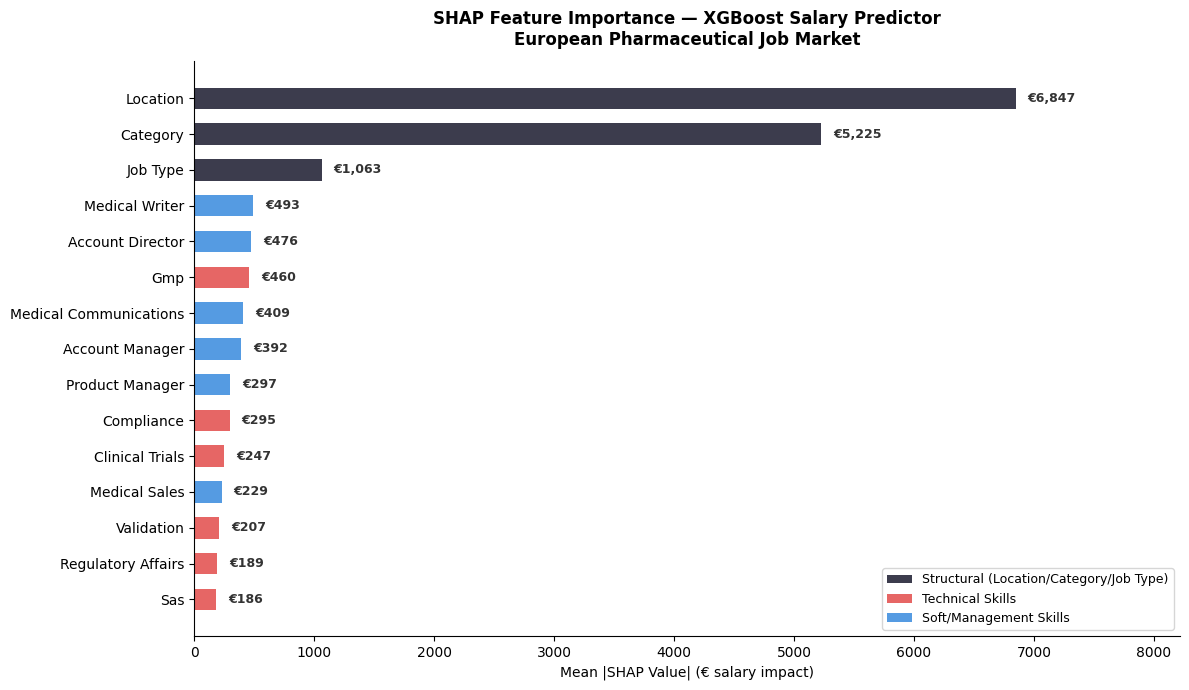

 Chart 1 → /content/rq3_shap_importance.png


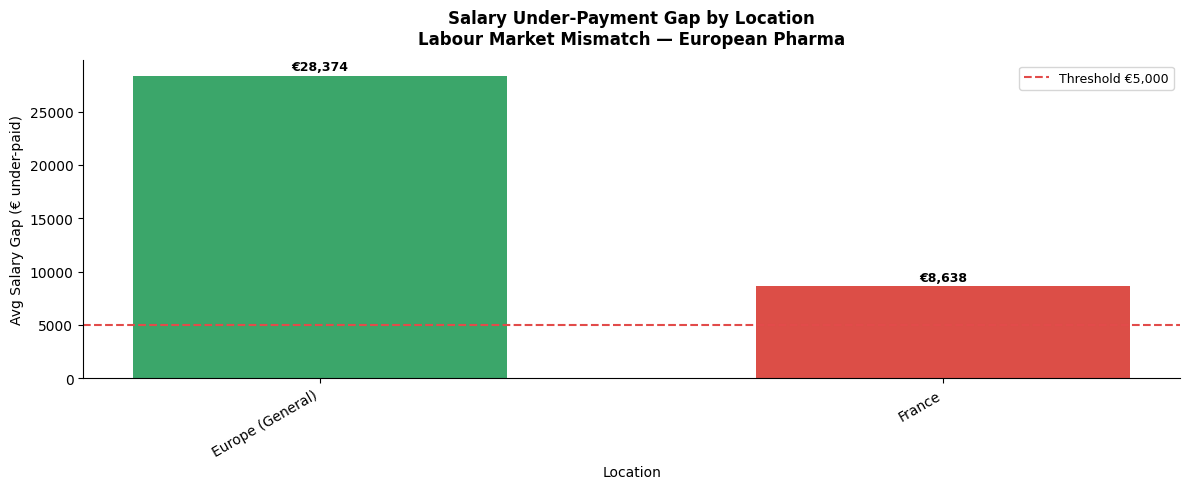

 Chart 2 → /content/rq3_mismatch_by_location.png


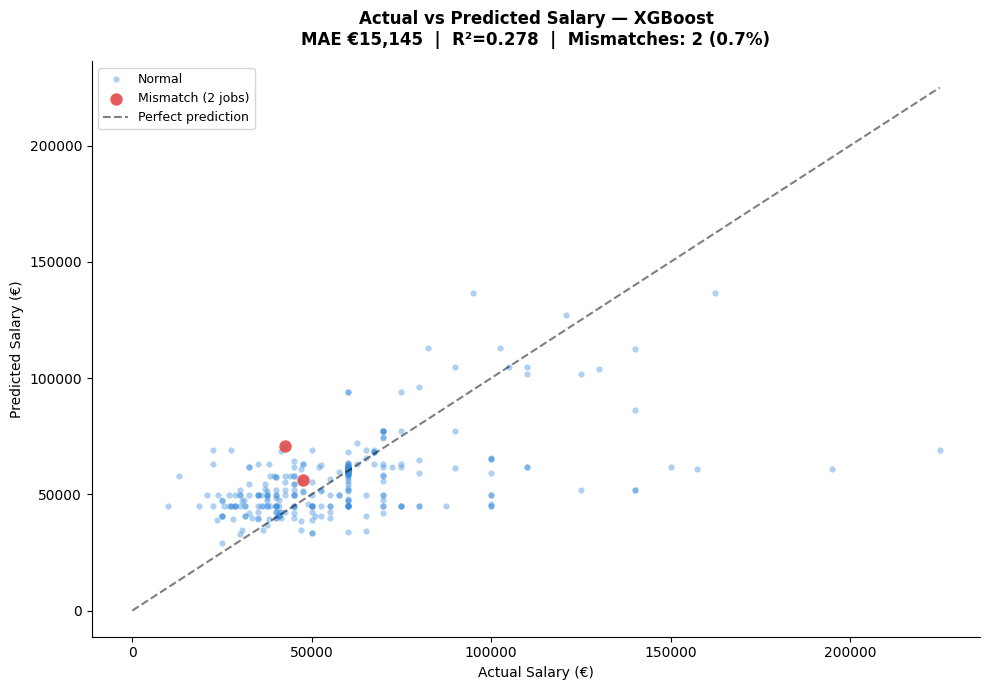

Chart 3 → /content/rq3_actual_vs_predicted.png


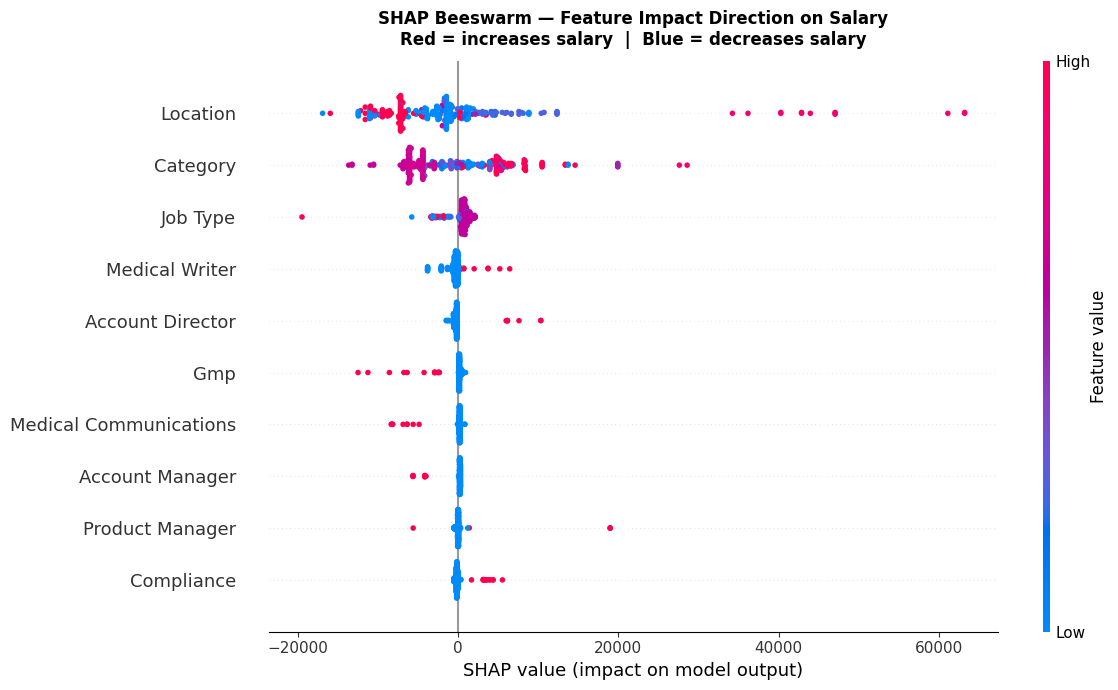

 Chart 4 → /content/rq3_shap_beeswarm.png



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/content/rq3_shap_importance.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

/content/rq3_actual_vs_predicted.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/content/rq3_shap_beeswarm.png


In [11]:
fig1, ax1 = plt.subplots(figsize=(12, 7), facecolor='white')
ax1.set_facecolor('white')
top15 = mean_shap.head(15)
colors_bar = ['#1A1A2E' if f in ['Location','Category','Job Type']
              else '#E24B4A' if any(s in f.lower() for s in
                   ['sas','gmp','clinical','gcp','validation',
                    'fda','compliance','iso','regulatory','data'])
              else '#378ADD'
              for f in top15.index]
bars = ax1.barh(top15.index[::-1], top15.values[::-1],
                color=colors_bar[::-1], alpha=0.85, height=0.6)
for bar, val in zip(bars, top15.values[::-1]):
    ax1.text(bar.get_width()+100, bar.get_y()+bar.get_height()/2,
             f"€{val:,.0f}", va='center', fontsize=9,
             fontweight='bold', color='#333333')
ax1.set_title('SHAP Feature Importance — XGBoost Salary Predictor\n'
              'European Pharmaceutical Job Market',
              fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Mean |SHAP Value| (€ salary impact)', fontsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xlim(0, top15.max() * 1.2)
legend_elements = [
    Patch(facecolor='#1A1A2E', alpha=0.85,
          label='Structural (Location/Category/Job Type)'),
    Patch(facecolor='#E24B4A', alpha=0.85,
          label='Technical Skills'),
    Patch(facecolor='#378ADD', alpha=0.85,
          label='Soft/Management Skills'),
]
ax1.legend(handles=legend_elements, fontsize=9, loc='lower right')
plt.tight_layout()
chart1_path = '/content/rq3_shap_importance.png'
plt.savefig(chart1_path, dpi=150, bbox_inches='tight', facecolor='white')
display(fig1)
plt.close()
print(f" Chart 1 → {chart1_path}")

if len(mismatch_by_loc) > 0:
    fig2, ax2 = plt.subplots(figsize=(12, 5), facecolor='white')
    ax2.set_facecolor('white')
    colors_loc = plt.cm.RdYlGn_r(
        np.linspace(0.1, 0.9, len(mismatch_by_loc))
    )
    bars2 = ax2.bar(mismatch_by_loc['location_clean'],
                    mismatch_by_loc['avg_gap'],
                    color=colors_loc, alpha=0.85, width=0.6)
    for bar, val in zip(bars2, mismatch_by_loc['avg_gap']):
        ax2.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+200, f"€{val:,.0f}",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax2.axhline(y=MISMATCH_THRESHOLD, color='#E24B4A', lw=1.5,
                ls='--', label=f'Threshold €{MISMATCH_THRESHOLD:,}')
    ax2.set_title('Salary Under-Payment Gap by Location\n'
                  'Labour Market Mismatch — European Pharma',
                  fontsize=12, fontweight='bold', pad=12)
    ax2.set_xlabel('Location', fontsize=10)
    ax2.set_ylabel('Avg Salary Gap (€ under-paid)', fontsize=10)
    ax2.legend(fontsize=9)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    chart2_path = '/content/rq3_mismatch_by_location.png'
    plt.savefig(chart2_path, dpi=150, bbox_inches='tight', facecolor='white')
    display(fig2)
    plt.close()
    print(f" Chart 2 → {chart2_path}")
else:
    chart2_path = None
    print("No mismatch location data — chart 2 skipped")

fig3, ax3 = plt.subplots(figsize=(10, 7), facecolor='white')
ax3.set_facecolor('white')
ax3.scatter(
    df_test[~df_test['is_mismatch']]['actual_salary'],
    df_test[~df_test['is_mismatch']]['predicted_salary'],
    alpha=0.4, s=20, color='#378ADD', label='Normal', linewidths=0
)
if mismatch_count > 0:
    ax3.scatter(
        df_test[df_test['is_mismatch']]['actual_salary'],
        df_test[df_test['is_mismatch']]['predicted_salary'],
        alpha=0.9, s=80, color='#E24B4A',
        label=f'Mismatch ({mismatch_count} jobs)', linewidths=0,
        zorder=5
    )
max_val = max(df_test['actual_salary'].max(),
              df_test['predicted_salary'].max())
ax3.plot([0, max_val], [0, max_val], 'k--',
         lw=1.5, alpha=0.5, label='Perfect prediction')
ax3.set_xlabel('Actual Salary (€)', fontsize=10)
ax3.set_ylabel('Predicted Salary (€)', fontsize=10)
ax3.set_title(f'Actual vs Predicted Salary — XGBoost\n'
              f'MAE €{mae:,.0f}  |  R²={r2:.3f}  |  '
              f'Mismatches: {mismatch_count} ({mismatch_pct:.1f}%)',
              fontsize=12, fontweight='bold', pad=12)
ax3.legend(fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
plt.tight_layout()
chart3_path = '/content/rq3_actual_vs_predicted.png'
plt.savefig(chart3_path, dpi=150, bbox_inches='tight', facecolor='white')
display(fig3)
plt.close()
print(f"Chart 3 → {chart3_path}")

fig4 = plt.figure(figsize=(12, 7), facecolor='white')
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_names,
                  max_display=10, show=False, plot_size=None)
plt.title('SHAP Beeswarm — Feature Impact Direction on Salary\n'
          'Red = increases salary  |  Blue = decreases salary',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
chart4_path = '/content/rq3_shap_beeswarm.png'
plt.savefig(chart4_path, dpi=150, bbox_inches='tight', facecolor='white')
display(fig4)
plt.close()
print(f" Chart 4 → {chart4_path}")

print(f"\n Downloading charts...")
for path in [chart1_path, chart2_path, chart3_path, chart4_path]:
    if path:
        try:
            files.download(path)
            print(f"{path}")
        except Exception as e:
            print(f"{path} — {e}")